# LC-MS Targeted Search
## Finding Specific Compounds by m/z and Retention Time

This notebook demonstrates how to perform targeted searches in LC-MS data using CoreMS. Targeted searches allow you to specifically look for compounds with known m/z and retention time values, such as internal standards or specific metabolites of interest.

### Workflow Overview
1. Load LC-MS data from Thermo RAW files
2. Configure parameters for targeted search
3. Define target compounds (m/z and retention time)
4. Perform targeted peak picking
5. Integrate and characterize target peaks
6. Associate MS2 data with targets
7. Visualize and export results

### Use Cases
- **Internal Standards**: Verify presence and quantify internal standards
- **Known Metabolites**: Target specific metabolites in complex samples
- **Quality Control**: Monitor specific compounds across batches
- **Spike-in Recovery**: Track spiked compounds through sample processing

### Data Format
This tutorial uses Thermo Fisher RAW format LC-MS data files. The targeted search approach is ideal when you have prior knowledge of expected compounds.

In [1]:
# Import required packages
import numpy as np
import shutil
from pathlib import Path

from corems.mass_spectra.input.rawFileReader import ImportMassSpectraThermoMSFileReader
from corems.mass_spectra.output.export import LCMSMetabolomicsExport
from corems.encapsulation.factory.parameters import LCMSParameters

## Step 1: Load LC-MS Data

First, we'll load the raw data file and create an LCMS object.

In [2]:
# Point to the data file location
file_path = '../../tests/tests_data/lcms/Blanch_Nat_Lip_C_12_AB_M_17_NEG_25Jan18_Brandi-WCSH5801.raw'

# Create parser for Thermo RAW files
parser = ImportMassSpectraThermoMSFileReader(file_path)

# Instantiate LCMS object with MS1 data
lcms_obj = parser.get_lcms_obj(spectra="ms1")

print(f"Loaded data file: {Path(file_path).name}")
print(f"Number of scans: {len(lcms_obj.scan_df)}")
print(f"Retention time range: {lcms_obj.scan_df.scan_time.min():.2f} - {lcms_obj.scan_df.scan_time.max():.2f} minutes")

Loaded data file: Blanch_Nat_Lip_C_12_AB_M_17_NEG_25Jan18_Brandi-WCSH5801.raw
Number of scans: 6840
Retention time range: 0.01 - 34.02 minutes


## Step 2: Configure Processing Parameters

Set parameters for data processing. For targeted searches, we can use faster settings since we're only looking for specific features.

In [3]:
# Set parameters to defaults for reproducible processing
lcms_obj.parameters = LCMSParameters(use_defaults=True)

# Configure persistent homology parameters for peak picking
lcms_obj.parameters.lc_ms.peak_picking_method = "persistent homology"
lcms_obj.parameters.lc_ms.ph_inten_min_rel = 0.0005
lcms_obj.parameters.lc_ms.ph_persis_min_rel = 0.05
lcms_obj.parameters.lc_ms.ph_smooth_it = 0

# Configure MS1 parameters
ms1_params = lcms_obj.parameters.mass_spectrum['ms1']
ms1_params.mass_spectrum.noise_threshold_method = "relative_abundance"
ms1_params.mass_spectrum.noise_threshold_min_relative_abundance = 0.1
ms1_params.mass_spectrum.noise_min_mz = 0
ms1_params.mass_spectrum.min_picking_mz = 0
ms1_params.mass_spectrum.noise_max_mz = np.inf
ms1_params.mass_spectrum.max_picking_mz = np.inf
ms1_params.ms_peak.legacy_resolving_power = False

# Configure MS2 parameters (same as MS1 for this dataset)
ms2_params = ms1_params.copy()
lcms_obj.parameters.mass_spectrum['ms2'] = ms2_params

print("✓ Parameters configured")

✓ Parameters configured


## Step 3: Define Target Compounds

Now we'll define the specific compounds we want to find. For each target, we need:
- **m/z value**: The expected mass-to-charge ratio
- **Retention time**: The expected elution time in minutes
- **Tolerances**: How much deviation to allow in m/z (ppm) and RT (minutes)
- **Type label**: A descriptive label for these targets (e.g., "internal standard")

In this example, we're targeting two compounds that we know exist in the data.

In [4]:
# Define target compounds
# These values are known to exist in our test dataset
target_mz_list = [
    301.2166,  # Target compound 1
    698.6289   # Target compound 2
]

target_rt_list = [
    8.8956,    # Expected RT for compound 1 (minutes)
    23.8168    # Expected RT for compound 2 (minutes)
]

# Create targeted search dictionary
target_search_dict = {
    "target_mz_list": target_mz_list,
    "target_rt_list": target_rt_list,
    "mz_tolerance_ppm": 5,      # Allow ±5 ppm deviation in m/z
    "rt_tolerance": 0.5,         # Allow ±0.5 minute deviation in RT
    "type": "internal standard"  # Label for these features
}

print(f"Targeting {len(target_mz_list)} compounds:")
for i, (mz, rt) in enumerate(zip(target_mz_list, target_rt_list), 1):
    print(f"  {i}. m/z = {mz:.4f}, RT = {rt:.4f} min")

Targeting 2 compounds:
  1. m/z = 301.2166, RT = 8.8956 min
  2. m/z = 698.6289, RT = 23.8168 min


## Step 4: Perform Targeted Peak Picking

Run the targeted search to find mass features that match our targets. The search will only look for features within the specified m/z and RT tolerances.

In [5]:
# Perform targeted search
lcms_obj.find_mass_features(
    targeted_search=True,
    target_search_dict=target_search_dict
)

print(f"✓ Found {len(lcms_obj.mass_features)} mass features matching target criteria")

Found 5 initial mass features
✓ Found 5 mass features matching target criteria


## Step 5: Integrate Mass Features

Integrate the chromatographic peaks to calculate areas, heights, and other quantitative metrics.

In [6]:
# Integrate the targeted mass features
lcms_obj.integrate_mass_features(drop_if_fail=True)

print(f"✓ Integrated {len(lcms_obj.mass_features)} mass features")
print("\nMass features after integration:")

# Display summary dataframe
mf_df = lcms_obj.mass_features_to_df()
mf_df.head()

✓ Integrated 3 mass features

Mass features after integration:


,type,scan_time,mz,apex_scan,start_scan,final_scan,intensity,persistence,area,tailing_factor,dispersity_index,normalized_dispersity_index,noise_score,noise_score_min,noise_score_max,monoisotopic_mf_id,isotopologue_type,mass_spectrum_deconvoluted_parent,ms2_scan_numbers
mf_id,,,,,,,,,,,,,,,,,,,
0,internal standard,8.895637,301.216614,1882.0,1828,2008,6.677533e+07,66768418.0,3.504558e+07,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,[]
1,internal standard,23.816803,698.628906,5212.0,5176,5338,1.726511e+07,17258196.0,7.113439e+06,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,[]
3,internal standard,23.337470,698.625427,5095.0,5059,5149,5.677616e+05,560851.0,2.312503e+05,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,[]


## Step 6: Verify Target Recovery

Check that we found features close to each of our targets and calculate the deviation from expected values.

In [7]:
# Verify that we found all targets
print("Target Recovery Summary:")
print("-" * 70)

for i, (target_mz, target_rt) in enumerate(zip(target_mz_list, target_rt_list), 1):
    # Calculate deviations
    mz_diff_ppm = abs(mf_df['mz'] - target_mz) / target_mz * 1e6
    rt_diff = abs(mf_df['scan_time'] - target_rt)
    
    # Find closest match
    closest_idx = (mz_diff_ppm + rt_diff * 100).idxmin()  # Combined score
    
    if mz_diff_ppm[closest_idx] < 10 and rt_diff[closest_idx] < 1.0:
        print(f"Target {i}: ✓ FOUND")
        print(f"  Expected: m/z = {target_mz:.4f}, RT = {target_rt:.4f} min")
        print(f"  Observed: m/z = {mf_df.loc[closest_idx, 'mz']:.4f}, RT = {mf_df.loc[closest_idx, 'scan_time']:.4f} min")
        print(f"  Deviation: Δm/z = {mz_diff_ppm[closest_idx]:.2f} ppm, ΔRT = {rt_diff[closest_idx]:.3f} min")
        print(f"  Intensity: {mf_df.loc[closest_idx, 'intensity']:.2e}")
    else:
        print(f"Target {i}: ✗ NOT FOUND within tolerance")
    print()

Target Recovery Summary:
----------------------------------------------------------------------
Target 1: ✓ FOUND
  Expected: m/z = 301.2166, RT = 8.8956 min
  Observed: m/z = 301.2166, RT = 8.8956 min
  Deviation: Δm/z = 0.05 ppm, ΔRT = 0.000 min
  Intensity: 6.68e+07

Target 2: ✓ FOUND
  Expected: m/z = 698.6289, RT = 23.8168 min
  Observed: m/z = 698.6289, RT = 23.8168 min
  Deviation: Δm/z = 0.01 ppm, ΔRT = 0.000 min
  Intensity: 1.73e+07



## Step 7: Add MS1 and MS2 Data

Add associated MS1 average spectra and MS2 fragmentation spectra to the mass features for further characterization.

In [8]:
# Since the search results are stored as mass features (in the lcms_obj.mass_features dictionary), we can now add associated MS1 and MS2 data to these features just like we would for untargeted features.
# Add MS1 average spectra
lcms_obj.add_associated_ms1(
    use_parser=False, 
    spectrum_mode="profile"
)
print(f"✓ Added MS1 spectra")

# Add MS2 DDA spectra
initial_ms_count = len(lcms_obj._ms)
lcms_obj.add_associated_ms2_dda(
    use_parser=True, 
    spectrum_mode="centroid"
)
ms2_added = len(lcms_obj._ms) - initial_ms_count
print(f"✓ Added {ms2_added} MS2 spectra")

# Check which mass features have MS2 data
ms2_counts = []
for mf_id, mf in lcms_obj.mass_features.items():
    ms2_count = len(mf.ms2_scan_numbers) if mf.ms2_scan_numbers else 0
    ms2_counts.append(ms2_count)
    
print(f"\nMS2 Data Summary:")
print(f"  Mass features with MS2: {sum(1 for c in ms2_counts if c > 0)} / {len(lcms_obj.mass_features)}")
print(f"  Total MS2 scans associated: {sum(ms2_counts)}")

✓ Added MS1 spectra
✓ Added 8 MS2 spectra

MS2 Data Summary:
  Mass features with MS2: 3 / 3
  Total MS2 scans associated: 8


## Step 8: Visualize Targeted Mass Features

Plot the extracted ion chromatograms (EICs) and mass spectra for the targeted compounds.

Plotting mass feature 0:
  m/z = 301.2168
  RT = 8.8956 min
  Intensity = 6.68e+07


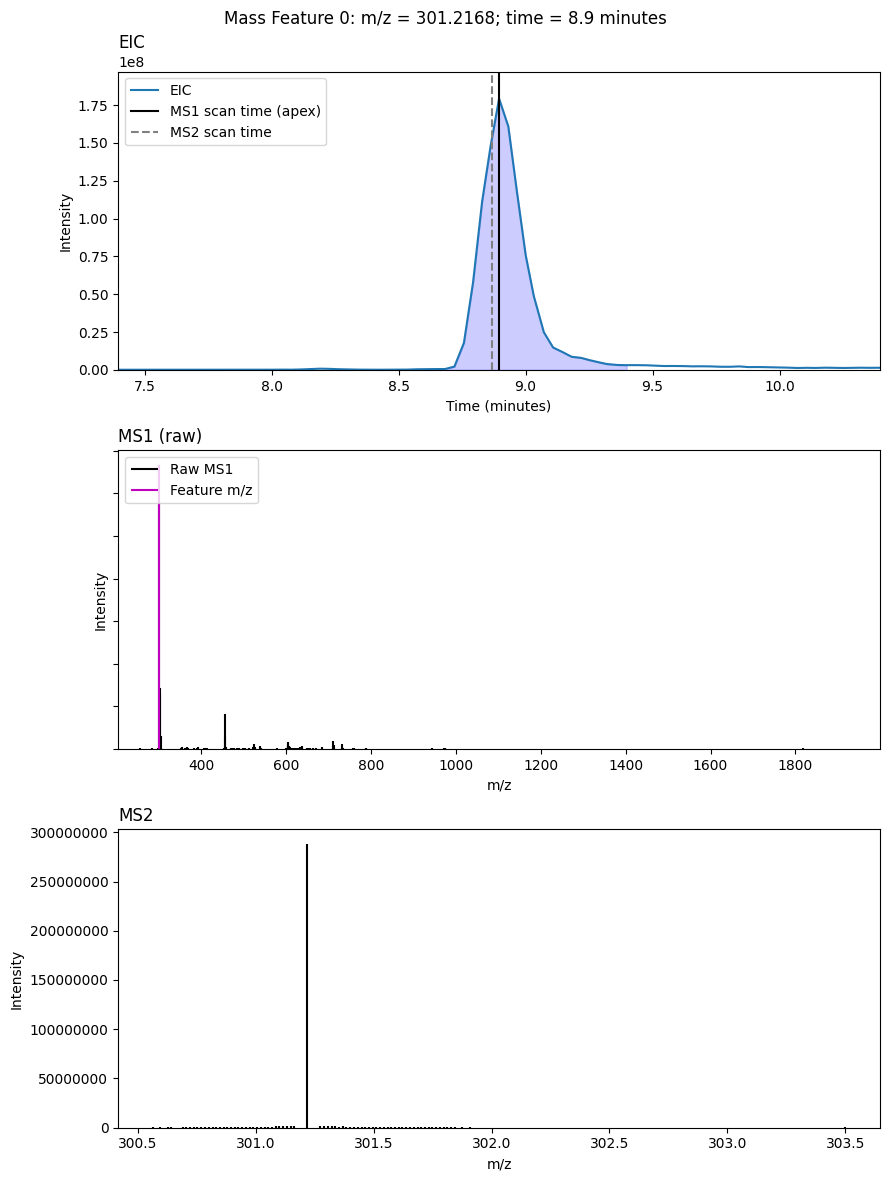

In [9]:
# Plot the first targeted mass feature
if len(lcms_obj.mass_features) > 0:
    first_mf_id = list(lcms_obj.mass_features.keys())[0]
    first_mf = lcms_obj.mass_features[first_mf_id]
    
    # Determine what to plot based on available data
    to_plot = ["EIC", "MS1"]
    if len(first_mf.ms2_mass_spectra) > 0:
        to_plot.append("MS2")
    
    print(f"Plotting mass feature {first_mf_id}:")
    print(f"  m/z = {first_mf.mz:.4f}")
    print(f"  RT = {first_mf.retention_time:.4f} min")
    print(f"  Intensity = {first_mf.intensity:.2e}")
    
    first_mf.plot(to_plot=to_plot, return_fig=False)

## Summary

This tutorial demonstrated:

1. ✓ **Targeted Search Setup**: Defining target compounds with m/z and RT values
2. ✓ **Selective Peak Picking**: Finding only features matching target criteria
3. ✓ **Integration & Quantification**: Calculating areas and intensities for targets
4. ✓ **Target Verification**: Confirming recovery and measuring deviations
5. ✓ **MS2 Association**: Linking fragmentation spectra to target compounds
6. ✓ **Data Export**: Saving results with persistent metadata
7. ✓ **Visualization**: Plotting EICs and spectra for quality control

### Key Advantages of Targeted Search

- **Speed**: Much faster than untargeted analysis (only processes specific regions)
- **Sensitivity**: Can use optimized parameters for known compounds
- **Quality Control**: Easily verify internal standards and spike-in recovery
- **Quantification**: Direct integration of known compounds for quantitative workflows
- **Organization**: Target features labeled with 'type' attribute for easy filtering

### Next Steps

- Use targeted search for internal standard verification in batch processing
- Combine with spectral library matching for MS2 confirmation
- Apply to quality control workflows for method validation
- Integrate with quantitative workflows for targeted metabolomics

### Parameters to Adjust

- `mz_tolerance_ppm`: Increase for lower resolution instruments or uncertain m/z values
- `rt_tolerance`: Increase for chromatographic drift or gradient variations
- `type`: Change label to categorize different target groups (e.g., "QC", "IS", "metabolite")